[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/penny/gavd3/01_gavd_manifest_and_youtube.ipynb)

# 01. GAVD manifests and YouTube source videos

Turn condition CSV folders into a sequence-level manifest, download each source once, and keep the original frame timeline intact.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `penny/gavd3/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "penny" / "gavd3"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD3_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD3_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "penny" / "gavd3" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD3_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD3_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/data-gavd
YouTube cache: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/youtube
artifacts: /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real


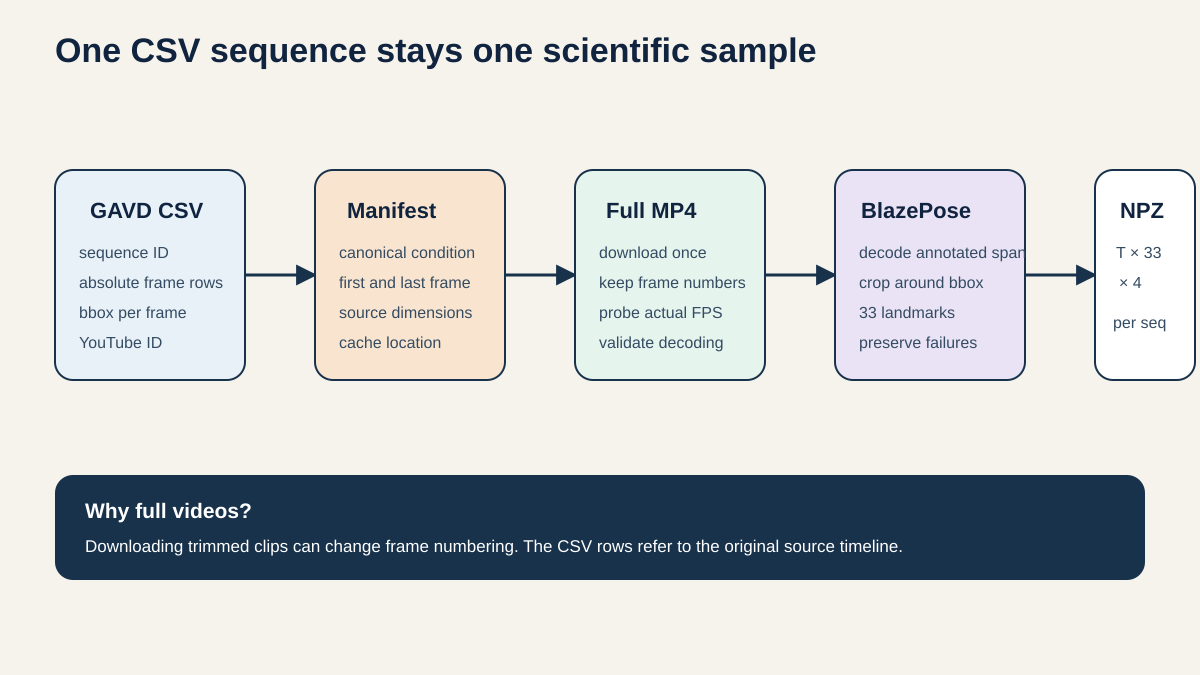

In [2]:
show_tutorial_svg("04_gavd_pipeline.svg")


In [3]:
import ast
from urllib.parse import parse_qs, urlparse

CONDITIONS = ["normal", "parkinsons", "stroke", "cerebralpalsy", "myopathic"]
CONDITION_ALIASES = {
    "normal": ["normal"],
    "parkinsons": ["parkinsons", "parkinson", "parkinsons disease"],
    "stroke": ["stroke"],
    "cerebralpalsy": ["cerebralpalsy", "cerebral palsy", "cerebral_palsy"],
    "myopathic": ["myopathic", "myopathy"],
}
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {
    "normal": 12,
    "parkinsons": 9,
    "stroke": 12,
    "cerebralpalsy": 16,
    "myopathic": 47,
}
EXPECTED_VIDEO_COUNTS = {
    "normal": 1,
    "parkinsons": 2,
    "stroke": 3,
    "cerebralpalsy": 2,
    "myopathic": 10,
}


def canonical_condition(value):
    compact = str(value).strip().lower().replace("_", " ")
    for canonical, aliases in CONDITION_ALIASES.items():
        if compact in [a.replace("_", " ") for a in aliases]:
            return canonical
    return compact.replace(" ", "")


def resolve_condition_folder(root, condition):
    root = Path(root)
    for alias in CONDITION_ALIASES[condition]:
        candidate = root / alias
        if candidate.exists():
            return candidate
    return root / condition


def youtube_id_from_url(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip()
    parsed = urlparse(text)
    if parsed.netloc.endswith("youtu.be"):
        value = parsed.path.strip("/").split("/")[0]
        return value if len(value) == 11 else None
    if "youtube.com" in parsed.netloc:
        value = parse_qs(parsed.query).get("v", [None])[0]
        return value if value and len(value) == 11 else None
    return text if len(text) == 11 else None


def safe_literal(value):
    if value is None or pd.isna(value):
        return {}
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, dict) else {}
    except (ValueError, SyntaxError):
        return {}


def selected_csv_paths(root=DATA_GAVD_DIR, cohort_root=COHORT_ROOT):
    """Resolve the fixed 96-sequence tutorial cohort against a data source."""
    paths = {}
    for condition in CONDITIONS:
        source_folder = resolve_condition_folder(root, condition)
        cohort_folder = resolve_condition_folder(cohort_root, condition)
        selected_ids = sorted(path.stem for path in cohort_folder.glob("*.csv"))
        expected = EXPECTED_SEQUENCE_COUNTS[condition]
        if len(selected_ids) != expected:
            raise ValueError(
                f"Tutorial cohort definition for {condition} has "
                f"{len(selected_ids)} sequences; expected {expected}: {cohort_folder}"
            )
        missing = [
            sequence_id for sequence_id in selected_ids
            if not (source_folder / f"{sequence_id}.csv").is_file()
        ]
        if missing:
            raise FileNotFoundError(
                f"Data source {source_folder} is missing {len(missing)} selected "
                f"{condition} sequences; first missing IDs: {missing[:5]}"
            )
        paths[condition] = [
            source_folder / f"{sequence_id}.csv"
            for sequence_id in selected_ids
        ]
    return paths


def scan_gavd_manifest(root=DATA_GAVD_DIR, cohort_root=COHORT_ROOT):
    rows = []
    selected_paths = selected_csv_paths(root, cohort_root)
    for condition in CONDITIONS:
        for csv_path in selected_paths[condition]:
            frame_table = pd.read_csv(csv_path)
            required = {"seq", "frame_num", "bbox", "id", "url"}
            missing = required.difference(frame_table.columns)
            if missing:
                raise ValueError(f"{csv_path} is missing {sorted(missing)}")
            if frame_table.empty:
                raise ValueError(f"Selected GAVD file is empty: {csv_path}")
            sequence_ids = frame_table["seq"].dropna().astype(str).unique()
            if len(sequence_ids) != 1:
                raise ValueError(f"{csv_path} contains {len(sequence_ids)} sequence ids")
            if sequence_ids[0] != csv_path.stem:
                raise ValueError(
                    f"Sequence ID {sequence_ids[0]} does not match filename {csv_path.stem}"
                )
            first = frame_table.iloc[0]
            video_id = youtube_id_from_url(first.get("id")) or youtube_id_from_url(first.get("url"))
            if video_id is None:
                raise ValueError(f"Could not parse a YouTube ID from {csv_path}")
            frames = pd.to_numeric(frame_table["frame_num"], errors="raise").astype(int)
            rows.append({
                "condition": condition,
                "dataset_annotation": first.get("dataset"),
                "gait_pattern_annotation": first.get("gait_pat"),
                "sequence_id": sequence_ids[0],
                "csv_path": str(csv_path),
                "video_id": video_id,
                "url": first.get("url"),
                "first_frame": int(frames.min()),
                "last_frame": int(frames.max()),
                "n_annotated_frames": int(frames.nunique()),
                "cam_view": first.get("cam_view"),
                "source_height": safe_literal(first.get("vid_info")).get("height"),
                "source_width": safe_literal(first.get("vid_info")).get("width"),
            })
    manifest = pd.DataFrame(rows)
    if manifest["sequence_id"].duplicated().any():
        raise ValueError("Sequence IDs must be unique across the selected conditions")
    actual_counts = manifest["condition"].value_counts().to_dict()
    if actual_counts != EXPECTED_SEQUENCE_COUNTS:
        raise ValueError(
            f"Selected cohort does not match the 96-sequence contract: {actual_counts}"
        )
    return manifest.sort_values(["condition", "sequence_id"]).reset_index(drop=True)


manifest = scan_gavd_manifest()


## One CSV is one sequence

The ten GAVD columns are:

seq, frame_num, cam_view, gait_event, dataset, gait_pat, bbox, vid_info, id, url

frame_num is a 1-based absolute frame number in the original source video. It is not relative to the sequence. The CSV has no FPS field, so notebook 02 probes the downloaded MP4.

The `condition` field comes from the folder chosen for this project. The original `dataset` and `gait_pat` values are retained as `dataset_annotation` and `gait_pattern_annotation`. These are dataset annotations, not diagnoses independently verified by this tutorial.

This notebook uses pandas directly. It does not call the legacy GAVD loader because that loader can download videos as a hidden side effect.


In [4]:
display(manifest.head())
manifest_path = ARTIFACT_DIR / "manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"wrote {manifest_path}")


,condition,dataset_annotation,gait_pattern_annotation,sequence_id,csv_path,video_id,url,first_frame,last_frame,n_annotated_frames,cam_view,source_height,source_width
0,cerebralpalsy,Abnormal Gait,cerebral palsy,cljar878f00c03n6ly2v2ay88,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,1,194,194,right side,720,1280
1,cerebralpalsy,Abnormal Gait,cerebral palsy,cljar9bqo00c43n6l2u5zmlru,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,234,428,195,left side,720,1280
2,cerebralpalsy,Abnormal Gait,cerebral palsy,cljar9t8o00c83n6ltculhoct,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,460,1100,641,right side,720,1280
3,cerebralpalsy,Abnormal Gait,cerebral palsy,cljarar9t00cc3n6lqhi9udoc,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,1246,2009,764,left side,720,1280
4,cerebralpalsy,Abnormal Gait,cerebral palsy,cljarbn1y00cg3n6l1u4i0d5l,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,2026,2177,152,front,720,1280


wrote /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real/manifest.csv


## Count sequences and independent source videos

Sequence count is not the same as independent-video count. This distinction matters because several annotated sequences can come from the same YouTube upload.


In [5]:
census = (
    manifest.groupby("condition")
    .agg(
        sequences=("sequence_id", "nunique"),
        annotated_frames=("n_annotated_frames", "sum"),
        unique_videos=("video_id", "nunique"),
    )
    .reindex(CONDITIONS)
)
actual_sequence_counts = census["sequences"].astype(int).to_dict()
actual_video_counts = census["unique_videos"].astype(int).to_dict()
if actual_sequence_counts != EXPECTED_SEQUENCE_COUNTS:
    raise ValueError(
        f"Unexpected tutorial sequence census: {actual_sequence_counts}"
    )
if actual_video_counts != EXPECTED_VIDEO_COUNTS:
    raise ValueError(
        f"Unexpected tutorial source-video census: {actual_video_counts}"
    )
display(census)
census.to_csv(ARTIFACT_DIR / "source_video_census.csv")
print("all selected sequences:", manifest["sequence_id"].nunique())
print("all selected videos:", manifest["video_id"].nunique())


,sequences,annotated_frames,unique_videos
condition,,,
normal,12,2598,1
parkinsons,9,1609,2
stroke,12,3609,3
cerebralpalsy,16,5546,2
myopathic,47,8871,10


all selected sequences: 96
all selected videos: 18


The experiment is locked to the 96 sequence IDs stored in the repository dataset, even when `DATA_GAVD_DIR` points to a larger mounted corpus. The selected files can therefore be read from either source without silently changing the experiment population. The cohort has only 18 source videos, and all 12 normal sequences come from one video. This blocks a valid video-disjoint five-class evaluation later.


In [6]:
video_concentration = (
    manifest.groupby(["condition", "video_id"])
    .size()
    .rename("sequences")
    .reset_index()
    .sort_values(["condition", "sequences"], ascending=[True, False])
)
display(video_concentration)
video_concentration.to_csv(
    ARTIFACT_DIR / "source_video_concentration.csv", index=False
)
normal_videos = manifest.loc[
    manifest["condition"].eq("normal"), "video_id"
].unique().tolist()
if len(normal_videos) != EXPECTED_VIDEO_COUNTS["normal"]:
    raise ValueError(
        f"Selected normal cohort has unexpected source videos: {normal_videos}"
    )


,condition,video_id,sequences
0,cerebralpalsy,DlPDuHBAP7A,8
1,cerebralpalsy,wRntYsztIEY,8
10,myopathic,R8LRCiTvUz8,12
4,myopathic,5qM6wxZ_dNs,8
8,myopathic,9qg-3smwLcs,6
5,myopathic,7Ft1bUTzxkM,5
7,myopathic,8PPLTf0fZsY,4
11,myopathic,jzJIpY6vRLo,4
9,myopathic,HDkWDe6FZDg,3
2,myopathic,05oyBOE_0UE,2


## Download each unique source once

Set GAVD3_MODE=real and GAVD_DOWNLOAD=1 in the root .env, or change DOWNLOAD_VIDEOS below. The full source is cached as youtube/condition/video_id.ext. Keeping the full video protects the CSV frame numbers. The downloader requests one progressive file with both video and audio, so this tutorial path does not require FFmpeg merging.

YouTube availability and terms can change. Download only material you are allowed to use.


In [7]:
import cv2
import json


VIDEO_SUFFIXES = {".mp4", ".mkv", ".webm", ".mov", ".m4v"}


def cached_video_path(condition, video_id):
    folder = Path(YOUTUBE_DIR) / condition
    exact = folder / f"{video_id}.mp4"
    if exact.exists() and exact.suffix.lower() in VIDEO_SUFFIXES:
        return exact
    matches = sorted(
        path for path in folder.glob(f"{video_id}.*")
        if path.suffix.lower() in VIDEO_SUFFIXES
        and not path.name.endswith(".part")
    )
    return matches[0] if matches else exact


def validate_video(path, required_last_frame=None):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return {"ok": False, "reason": "missing or empty"}
    cap = cv2.VideoCapture(str(path))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ok, _ = cap.read()
    cap.release()
    reaches_annotation = (
        required_last_frame is None or frames >= int(required_last_frame)
    )
    return {
        "ok": bool(ok and fps > 0 and frames > 0 and reaches_annotation),
        "fps": fps,
        "frames": frames,
        "required_last_frame": required_last_frame,
        "reaches_annotation": reaches_annotation,
        "size_mb": path.stat().st_size / 1_000_000,
    }


def saved_format_metadata(condition, video_id):
    info_path = Path(YOUTUBE_DIR) / condition / f"{video_id}.info.json"
    if not info_path.exists():
        return {}
    info = json.loads(info_path.read_text(encoding="utf-8"))
    return {
        "format_id": info.get("format_id"),
        "format_note": info.get("format_note"),
        "download_fps": info.get("fps"),
        "download_width": info.get("width"),
        "download_height": info.get("height"),
    }


def download_unique_videos(table, max_videos=None):
    from yt_dlp import YoutubeDL

    unique = (
        table.groupby(["condition", "video_id", "url"], as_index=False)
        .agg(required_last_frame=("last_frame", "max"))
    )
    if max_videos is not None:
        unique = unique.head(max_videos)
    results = []
    for row in unique.itertuples(index=False):
        folder = Path(YOUTUBE_DIR) / row.condition
        folder.mkdir(parents=True, exist_ok=True)
        destination = cached_video_path(row.condition, row.video_id)
        status = validate_video(destination, row.required_last_frame)
        if status.get("ok"):
            results.append({
                **row._asdict(),
                "status": "cached",
                **saved_format_metadata(row.condition, row.video_id),
                **status,
            })
            continue
        options = {
            "outtmpl": str(folder / "%(id)s.%(ext)s"),
            "format": (
                "best[ext=mp4][vcodec!=none][acodec!=none]/"
                "best[vcodec!=none][acodec!=none]"
            ),
            "noplaylist": True,
            "writeinfojson": True,
            "quiet": False,
        }
        with YoutubeDL(options) as downloader:
            info = downloader.extract_info(row.url, download=True)
        destination = cached_video_path(row.condition, row.video_id)
        results.append({
            **row._asdict(),
            "status": "downloaded",
            "format_id": info.get("format_id"),
            "format_note": info.get("format_note"),
            "download_fps": info.get("fps"),
            "download_width": info.get("width"),
            "download_height": info.get("height"),
            **validate_video(destination, row.required_last_frame),
        })
    return pd.DataFrame(results)


def audit_cached_videos(table):
    unique = (
        table.groupby(["condition", "video_id", "url"], as_index=False)
        .agg(required_last_frame=("last_frame", "max"))
    )
    rows = []
    for row in unique.itertuples(index=False):
        path = cached_video_path(row.condition, row.video_id)
        rows.append({
            **row._asdict(),
            "path": str(path),
            **saved_format_metadata(row.condition, row.video_id),
            **validate_video(path, row.required_last_frame),
        })
    return pd.DataFrame(rows)


DOWNLOAD_VIDEOS = MODE == "real" and os.getenv("GAVD_DOWNLOAD", "0") == "1"
MAX_VIDEOS = None
if DOWNLOAD_VIDEOS:
    download_report = download_unique_videos(manifest, MAX_VIDEOS)
    display(download_report)
    assert download_report["ok"].all()
else:
    print("Download skipped. Set GAVD3_MODE=real and GAVD_DOWNLOAD=1 to enable it.")
    download_report = audit_cached_videos(manifest)
    display(download_report)
download_report.to_csv(
    ARTIFACT_DIR / "video_download_audit.csv", index=False
)


Download skipped. Set GAVD3_MODE=real and GAVD_DOWNLOAD=1 to enable it.


,condition,video_id,url,required_last_frame,path,ok,fps,frames,reaches_annotation,size_mb
0,cerebralpalsy,DlPDuHBAP7A,https://www.youtube.com/watch?v=DlPDuHBAP7A,2974,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,29.970030,3572,True,5.511548
1,cerebralpalsy,wRntYsztIEY,https://www.youtube.com/watch?v=wRntYsztIEY,3891,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,4193,True,6.235969
2,myopathic,05oyBOE_0UE,https://www.youtube.com/watch?v=05oyBOE_0UE,4213,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,29.970030,5981,True,9.774748
3,myopathic,4Yiqk-ud8rI,https://www.youtube.com/watch?v=4Yiqk-ud8rI,649,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,1509,True,2.644798
4,myopathic,5qM6wxZ_dNs,https://www.youtube.com/watch?v=5qM6wxZ_dNs,1709,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,1906,True,3.376793
5,myopathic,7Ft1bUTzxkM,https://www.youtube.com/watch?v=7Ft1bUTzxkM,828,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,23.976024,835,True,1.680514
6,myopathic,8NlJgIySMG0,https://www.youtube.com/watch?v=8NlJgIySMG0,1022,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,1022,True,1.011996
7,myopathic,8PPLTf0fZsY,https://www.youtube.com/watch?v=8PPLTf0fZsY,493,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,506,True,0.705329
8,myopathic,9qg-3smwLcs,https://www.youtube.com/watch?v=9qg-3smwLcs,2321,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,29.970030,2421,True,5.934015
9,myopathic,HDkWDe6FZDg,https://www.youtube.com/watch?v=HDkWDe6FZDg,677,/Users/pmui/vaults/worldmodels/gait/skeleton-j...,True,30.000000,922,True,1.222094


## Preview a walk in context

The local player is preferred because it shows the exact cached source that pose extraction will use. A YouTube player is a contextual fallback before download.


Cached source: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/youtube/normal/3KnFt8bH3tE.mp4
The remote player provides context here. Notebook 02 creates an embedded short clip from the exact cached source.


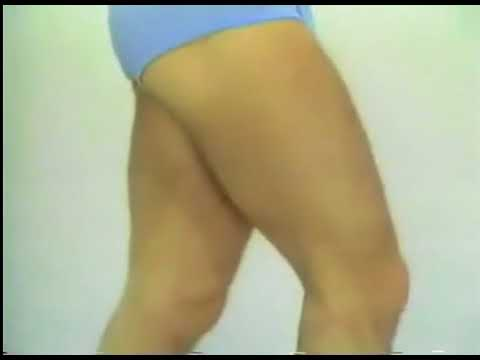

In [8]:
from IPython.display import YouTubeVideo, display


def show_source_video(row, width=720):
    path = cached_video_path(row["condition"], row["video_id"])
    if path.exists():
        print("Cached source:", path)
        print(
            "The remote player provides context here. Notebook 02 "
            "creates an embedded short clip from the exact cached source."
        )
    else:
        print("Cached MP4 is absent. Showing the remote source.")
    display(YouTubeVideo(
        row["video_id"], width=width, height=int(width * 9 / 16)
    ))


example = manifest.loc[manifest["condition"].eq("normal")].iloc[0]
show_source_video(example)


## Checkpoint before moving on

- manifest.csv has one row per sequence.
- Conditions use the canonical spelling cerebralpalsy.
- Cached files are separated by condition and named by YouTube ID.
- Each cached video opens, has a positive FPS, and contains frames.
- The source-video census is saved beside the scientific results.

Notebook 02 uses each CSV's annotated frame span and bbox. It does not process an entire YouTube video as one sample.
